In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
types = {'InvoiceNo': 'string', 'StockCode': 'string', 'CustomerID': 'string'}
df = pd.read_csv('../data/clean_all.csv', parse_dates=['InvoiceDate'], dtype=types)
sales = pd.read_csv('../data/sales.csv', parse_dates=['InvoiceDate'], dtype=types)
returns = pd.read_csv('../data/returns.csv', parse_dates=['InvoiceDate'], dtype=types)

print(sales.shape, returns.shape)

(522685, 18) (8670, 18)


# 1. Customer-Level Feature Engineering

In [26]:
snapshot = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print('Snapshot date:', snapshot)

known_sales = sales[sales['CustomerID'].notna()]
known_ret = returns[returns['CustomerID'].notna()]

cf = known_sales.groupby('CustomerID').agg(
    LastPurchase=('InvoiceDate', 'max'),
    Frequency=('InvoiceNo', 'nunique'),      # unique invoices, not rows
    GrossRevenue=('TotalLineRevenue', 'sum'),
    TotalUnits=('Quantity', 'sum'),
    UniqueProducts=('StockCode', 'nunique'))

cf['Recency'] = (snapshot - cf['LastPurchase']).dt.days
cf['ReturnValue'] = known_ret.groupby('CustomerID')['TotalLineRevenue'].sum().reindex(cf.index).fillna(0)
cf['Monetary'] = cf['GrossRevenue'] + cf['ReturnValue']         # net of returns
cf['AOV'] = cf['GrossRevenue'] / cf['Frequency']
cf['Country'] = known_sales.groupby('CustomerID')['Country'].agg(lambda x: x.mode().iloc[0])
cf['Is_UK'] = (cf['Country'] == 'United Kingdom').astype(int)

print('Customers:', len(cf))
print('Customers with Monetary <= 0 (returned more than they bought):', (cf['Monetary'] <= 0).sum())

Snapshot date: 2011-12-10 12:50:00
Customers: 4334
Customers with Monetary <= 0 (returned more than they bought): 14


In [27]:
# log needs positive values, and a customer with zero or negative net revenue is not a real buyer
rfm = cf[cf['Monetary'] > 0].copy()
print('Customers used for RFM:', len(rfm))
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(1)

Customers used for RFM: 4320


,Recency,Frequency,Monetary
count,4320.0,4320.0,4320.0
mean,92.5,4.3,1915.8
std,100.1,7.7,8320.7
min,1.0,1.0,2.9
25%,18.0,1.0,299.5
50%,51.0,2.0,650.6
75%,143.0,5.0,1610.5
max,374.0,206.0,278778.0


**Decision:** Monetary is net of returns. I removed the few customers whose net revenue is 0 or negative, because they returned more than they bought and the log transform cannot handle them.

# 2. RFM Analysis

- **Recency (R):** days since the last purchase (small is good)
- **Frequency (F):** number of unique invoices
- **Monetary (M):** total net revenue

I split each one into 5 groups with `pd.qcut` and give scores 1 to 5.
**For Recency the score is reversed: 5 = bought most recently, 1 = bought a long time ago.** For F and M, 5 = highest.

In [28]:
# Many customers have the same Frequency (for example 1 or 2 orders), so qcut would fail on duplicate edges.
# I rank first (method='first') so every group gets a fair size.
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm[['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12347,2,7,4310.00,5,5,5,555
12348,75,4,1437.24,2,4,4,244
12349,19,1,1457.55,4,1,4,414
12350,310,1,294.40,1,1,2,112
12352,36,7,1265.41,3,5,4,354
12353,204,1,89.00,1,1,1,111
12354,232,1,1079.40,1,1,4,114
12355,214,1,459.40,1,1,2,112
12356,23,3,2487.43,4,3,5,435


In [29]:
print('Customers with score 555:', (rfm['RFM_Score'] == '555').sum())
print('Customers with score 111:', (rfm['RFM_Score'] == '111').sum())
rfm.groupby('R_Score')['Recency'].agg(['min', 'max']).rename(columns={'min': 'Min days', 'max': 'Max days'})

Customers with score 555: 346
Customers with score 111: 187


,Min days,Max days
R_Score,,
1,179,374
2,71,179
3,33,71
4,14,33
5,1,13


**How to read the score:** '555' = bought recently, buys often and spends a lot (best). '111' = bought long ago, bought rarely and spent little (worst). '155' = spent a lot and often, but not recently (maybe lost).

In [30]:
# Rule based groups using the scores (based on the business translation matrix from the guideline)
def rfm_group(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At-Risk High-Value'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Inflow'
    elif r <= 2 and f <= 2:
        return 'Lost / Low-Value'
    else:
        return 'Needs Attention'

rfm['RFM_Group'] = rfm.apply(rfm_group, axis=1)
rfm['RFM_Group'].value_counts()

RFM_Group
Lost / Low-Value      1072
Loyal Customers        996
Champions              940
Needs Attention        542
At-Risk High-Value     461
New Inflow             309
Name: count, dtype: int64

# 3. RFM Visualization & Interpretation

In [31]:
grp = rfm.groupby('RFM_Group').agg(
    Customers=('Recency', 'size'),
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    TotalRevenue=('Monetary', 'sum'))
grp['%Customers'] = grp['Customers'] / grp['Customers'].sum() * 100
grp['%Revenue'] = grp['TotalRevenue'] / grp['TotalRevenue'].sum() * 100
grp = grp.sort_values('TotalRevenue', ascending=False)
grp.round(1)

,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue,%Customers,%Revenue
RFM_Group,,,,,,,
Champions,940,12.5,11.1,5872.3,5519918.1,21.8,66.7
Loyal Customers,996,33.3,3.7,1266.5,1261469.2,23.1,15.2
At-Risk High-Value,461,137.7,3.8,1552.0,715462.8,10.7,8.6
Lost / Low-Value,1072,217.1,1.1,401.3,430235.2,24.8,5.2
Needs Attention,542,98.0,1.6,389.4,211047.2,12.5,2.6
New Inflow,309,18.1,1.2,447.1,138140.9,7.2,1.7


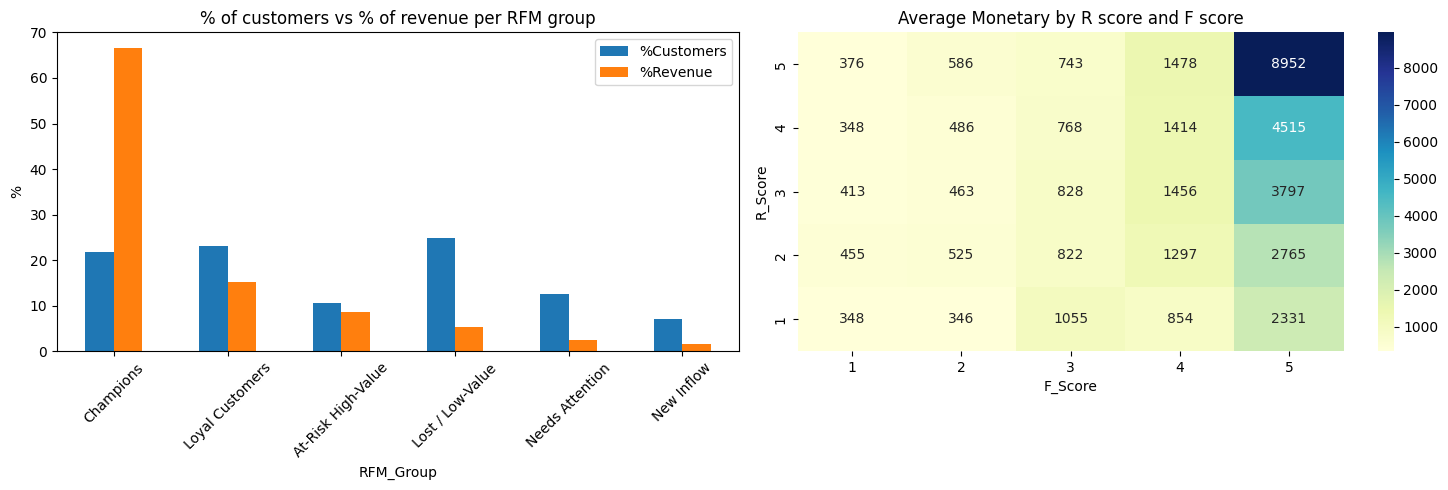

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
grp[['%Customers', '%Revenue']].plot(kind='bar', ax=ax[0])
ax[0].set_title('% of customers vs % of revenue per RFM group')
ax[0].set_ylabel('%')
ax[0].tick_params(axis='x', rotation=45)

heat = rfm.pivot_table(index='R_Score', columns='F_Score', values='Monetary', aggfunc='mean')
sns.heatmap(heat.sort_index(ascending=False), annot=True, fmt='.0f', cmap='YlGnBu', ax=ax[1])
ax[1].set_title('Average Monetary by R score and F score')
plt.tight_layout()
plt.show()

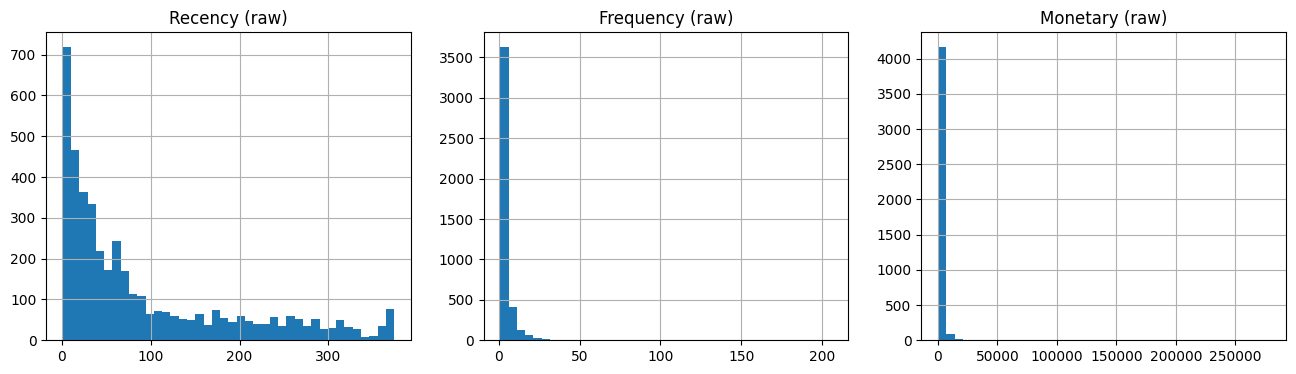

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, col in zip(ax, ['Recency', 'Frequency', 'Monetary']):
    rfm[col].hist(bins=40, ax=a)
    a.set_title(col + ' (raw)')
plt.show()

**Interpretation:**
- The chart on the left shows that a small share of customers (Champions and Loyal) brings a much bigger share of revenue, while the lost / low value group is large in number but small in revenue.
- In the heatmap, the average spend grows a lot as Frequency score goes up. Recency matters less for the amount spent, but it tells us who is still active.
- The raw R, F and M histograms are heavily skewed to the right, so I need to transform them before clustering.
- The groups above come from simple rules on the scores, so they are a starting point. In the next sections I let the algorithm find groups from the data itself.

In [34]:
rfm.to_csv('../data/rfm.csv')    # keeps CustomerID as the index